In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import win32com.client as win32
import pandas as pd

In [ ]:
aspen = win32.Dispatch('Apwn.Document')
path = os.path.join("aspen_model", "water_ethanol_automation.bkp")
aspen.InitFromArchive2(os.path.abspath(path))

In [3]:
temps = np.linspace(94, 99, 15)
pressures = np.linspace(1.5, 2.5, 15)

In [4]:
final_list = []

for temp in temps:
    for pressure in pressures:
        list_per_pres = []
        aspen.Tree.FindNode('\Data\Blocks\FLASH1\Input\TEMP').value = temp
        aspen.Tree.FindNode('\Data\Blocks\FLASH1\Input\PRES').value = pressure
        aspen.Engine.Run2()
        ethanol_vapor_frac = aspen.Tree.FindNode("\Data\Streams\VAPOR\Output\MOLEFRAC\MIXED\ETHANOL").value
        ethanol_vapor_flow = aspen.Tree.FindNode("\Data\Streams\VAPOR\Output\MOLEFLOW\MIXED\ETHANOL").value
        ethanol_liq_frac = aspen.Tree.FindNode("\Data\Streams\LIQUID\Output\MOLEFRAC\MIXED\ETHANOL").value
        ethanol_liq_flow = aspen.Tree.FindNode("\Data\Streams\LIQUID\Output\MOLEFLOW\MIXED\ETHANOL").value
        final_list.append([float(temp), float(pressure), ethanol_vapor_frac, ethanol_vapor_flow, ethanol_liq_frac, ethanol_liq_flow])
print(final_list)





[[94.0, 1.5, 0.516799072, 49.1754407, 0.170148597, 0.82455926], [94.0, 1.5714285714285714, 0.551294567, 46.2908523, 0.231352471, 3.70914768], [94.0, 1.6428571428571428, 0.588466747, 38.9529173, 0.326777928, 11.0470827], [94.0, 1.7142857142857142, 0.63486798, 14.8150557, 0.458947912, 35.1849443], [94.0, 1.7857142857142856, 0.0, 0.0, 0.5, 50.0], [94.0, 1.8571428571428572, 0.0, 0.0, 0.5, 50.0], [94.0, 1.9285714285714286, 0.0, 0.0, 0.5, 50.0], [94.0, 2.0, 0.0, 0.0, 0.5, 50.0], [94.0, 2.071428571428571, 0.0, 0.0, 0.5, 50.0], [94.0, 2.142857142857143, 0.0, 0.0, 0.5, 50.0], [94.0, 2.2142857142857144, 0.0, 0.0, 0.5, 50.0], [94.0, 2.2857142857142856, 0.0, 0.0, 0.5, 50.0], [94.0, 2.357142857142857, 0.0, 0.0, 0.5, 50.0], [94.0, 2.4285714285714284, 0.0, 0.0, 0.5, 50.0], [94.0, 2.5, 0.0, 0.0, 0.5, 50.0], [94.35714285714286, 1.5, 0.507343448, 49.6691067, 0.157595343, 0.330893327], [94.35714285714286, 1.5714285714285714, 0.541273048, 47.3605797, 0.211128285, 2.63942031], [94.35714285714286, 1.6428571

In [5]:
df = pd.DataFrame(final_list, columns=[
    "Temperature",
    "Pressure",
    "Vapor Ethanol Fraction",
    "Vapor Ethanol Flow",
    "Liquid Ethanol Fraction",
    "Liquid Ethanol Flow"
])

print(df.columns)



Index(['Temperature', 'Pressure', 'Vapor Ethanol Fraction',
       'Vapor Ethanol Flow', 'Liquid Ethanol Fraction', 'Liquid Ethanol Flow'],
      dtype='object')


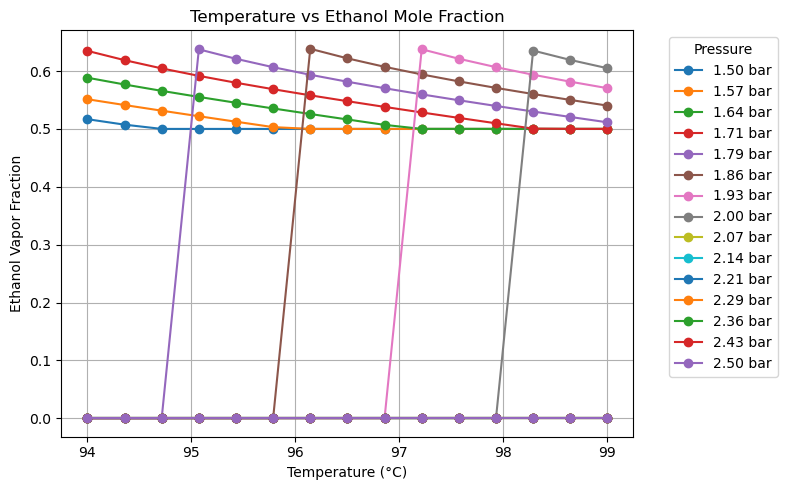

In [6]:
plt.figure(figsize=(8,5))

for p in sorted(df["Pressure"].unique()):
    subset = df[df["Pressure"] == p]
    plt.plot(subset["Temperature"], subset["Vapor Ethanol Fraction"], marker= "o", label=f"{p:.2f} bar")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ethanol Vapor Fraction")
plt.title("Temperature vs Ethanol Mole Fraction")
plt.grid(True)
plt.legend(title="Pressure", bbox_to_anchor = (1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()




In [32]:
best = df.loc[df["Vapor Ethanol Fraction"].idxmax()]
print("The optimal temperature is " + str(best["Temperature"]) + "." + " " + "The highest vapor fraction is " + str(best["Vapor Ethanol Fraction"]) + "." + " " + "The optimal pressure is ", str(best["Pressure"]) + ".")

The optimal temperature is 96.14285714285714. The highest vapor fraction is 0.638430676. The optimal pressure is  1.8571428571428572.


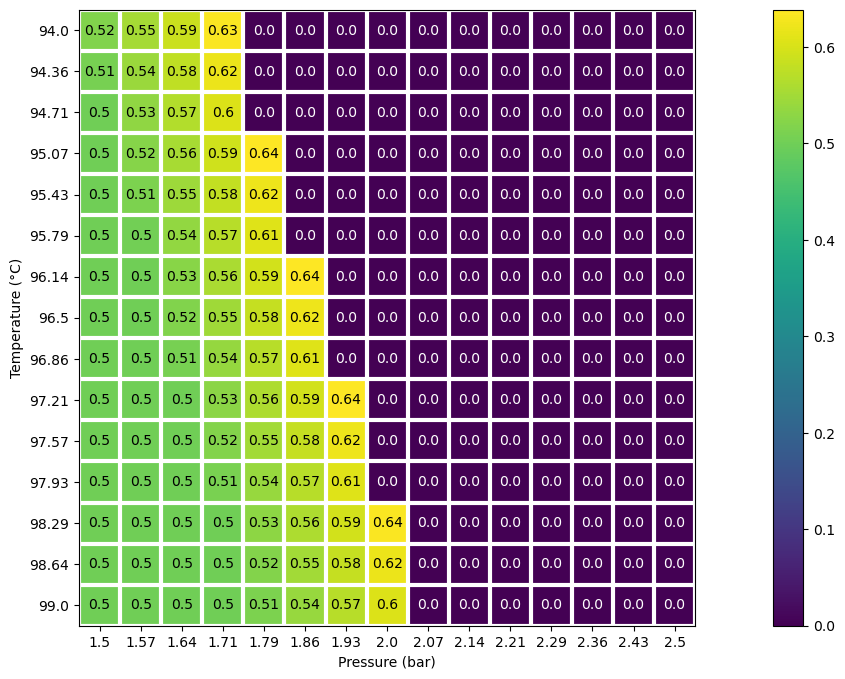

In [17]:
heatmap = df.pivot(
    index="Temperature",
    columns="Pressure",
    values="Vapor Ethanol Fraction"
).round(4)
fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(heatmap)
ax.set_xticks(range(len(heatmap.columns)), labels=heatmap.columns.round(2))
ax.set_yticks(range(len(heatmap.index)), labels = heatmap.index.round(2))
ax.set_xticks(np.arange(len(pressures)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(temps)+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)

values = heatmap.values
for i in range(len(temps)):
    for j in range(len(pressures)):
        value = values[i, j]
        if value < 0.3:
            color = "w"
        else:
            color = "black"
        text = ax.text(j , i, values[i, j].round(2), ha="center", va="center", color=color)


plt.colorbar(im)
plt.xlabel("Pressure (bar)")
plt.ylabel("Temperature (°C)")
plt.show()


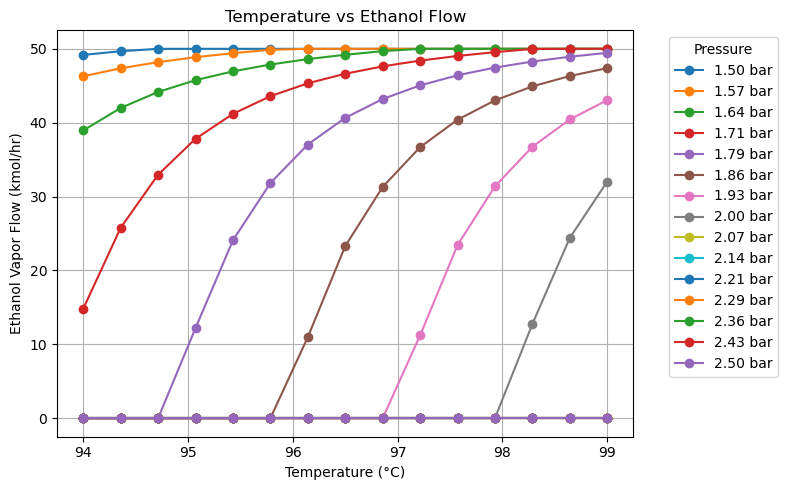

In [9]:
plt.figure(figsize=(8,5))
for p in sorted(df["Pressure"].unique()):
    subset = df[df["Pressure"] == p]
    plt.plot(subset["Temperature"], subset["Vapor Ethanol Flow"], marker= "o", label=f"{p:.2f} bar")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ethanol Vapor Flow (kmol/hr)")
plt.title("Temperature vs Ethanol Flow")
plt.grid(True)
plt.legend(title="Pressure", bbox_to_anchor = (1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
aspen.Close()
del aspen
